# Pre-filtering Demo using MaxInfo Module

This notebook demonstrates video pre-filtering (change-based deduplication) using the MaxInfo module.

## Overview

Pre-filtering reduces computational cost by:
1. Sampling frames at a target FPS
2. Computing pixel change scores between consecutive frames
3. Keeping only frames with sufficient visual change
4. Passing the filtered frames to MaxInfo for keyframe selection

This reduces the number of frames that need expensive CLIP embedding extraction.

In [ ]:
# Install dependencies (if running in Colab)
# !pip install decord transformers torch pillow scipy matplotlib numpy opencv-python


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\yazan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
# Imports
import numpy as np
import cv2
import matplotlib.pyplot as plt
from math import ceil

# MaxInfo module imports
from maxinfo import (
    load_video_segment,
    encode_video_candidates,
    uniform_select,
    maxinfo_select_rect_maxvol,
)

print("MaxInfo module imported successfully")

MaxInfo module imported successfully


## Pre-filtering Functions

These functions perform pixel-based change detection to filter out similar frames before MaxInfo selection.

In [3]:
def change_dedup_indices(
    frames_np: np.ndarray,
    resize_hw=(32, 32),
    change_threshold: float = 6.0,
    keep_first: bool = True,
):
    """
    Decide which consecutive frames to keep based on pixel change.

    Args:
        frames_np: np.ndarray of shape (T, H, W, 3) RGB uint8
        resize_hw: Tuple (height, width) to resize frames for comparison
        change_threshold: Minimum mean pixel difference to keep a frame
        keep_first: Whether to always keep the first frame

    Returns:
        keep_mask: np.ndarray[bool] of length T
        change_scores: list[float] length T-1
    """
    T = len(frames_np)

    if T == 0:
        return np.zeros((0,), dtype=bool), []

    keep = np.zeros((T,), dtype=bool)

    if keep_first:
        keep[0] = True

    change_scores = []

    prev = cv2.cvtColor(frames_np[0], cv2.COLOR_RGB2GRAY)
    prev = cv2.resize(prev, resize_hw, interpolation=cv2.INTER_AREA)

    for i in range(1, T):
        curr = cv2.cvtColor(frames_np[i], cv2.COLOR_RGB2GRAY)
        curr = cv2.resize(curr, resize_hw, interpolation=cv2.INTER_AREA)

        diff = float(np.mean(np.abs(curr.astype(np.float32) - prev.astype(np.float32))))
        change_scores.append(diff)

        if diff >= change_threshold:
            keep[i] = True
            prev = curr  # update reference only when we keep

    return keep, change_scores


def apply_prefilter(
    video_path: str,
    fps_sample: float = 1.0,
    max_candidates: int = 256,
    start_sec: float | None = None,
    end_sec: float | None = None,
    resize_hw=(32, 32),
    change_threshold: float = 6.0,
    keep_first: bool = True,
    progress: bool = True,
):
    """
    Apply pre-filtering to a video segment.

    Args:
        video_path: Path to video file
        fps_sample: FPS at which to sample frames
        max_candidates: Maximum number of candidate frames
        start_sec: Start time in seconds (None for beginning)
        end_sec: End time in seconds (None for end)
        resize_hw: Size for frame comparison
        change_threshold: Pixel change threshold for filtering
        keep_first: Always keep first frame
        progress: Show progress

    Returns:
        dict with filtered frames, metadata, and change scores
    """
    if progress:
        print("=" * 60)
        print(f"Pre-filtering: {video_path}")
        print(f"   Sample FPS: {fps_sample}, Max candidates: {max_candidates}")
        print(f"   Change threshold: {change_threshold}, Resize: {resize_hw}")
        print("=" * 60)

    # Load video segment using MaxInfo module
    frames_np, timestamps, orig_frame_idx, segment, duration, native_fps = load_video_segment(
        video_path=video_path,
        fps_sample=fps_sample,
        max_candidates=max_candidates,
        start_sec=start_sec,
        end_sec=end_sec,
        force_sample=True,
    )

    initial_n = len(frames_np)

    if progress:
        print(f"Loaded {initial_n} frames from segment")

    # Apply change-based deduplication
    if initial_n > 1:
        keep_mask, change_scores = change_dedup_indices(
            frames_np,
            resize_hw=resize_hw,
            change_threshold=change_threshold,
            keep_first=keep_first,
        )

        # Filter frames
        filtered_frames = frames_np[keep_mask]
        filtered_timestamps = [t for t, k in zip(timestamps, keep_mask) if k]
        filtered_orig_idx = [fi for fi, k in zip(orig_frame_idx, keep_mask) if k]
    else:
        keep_mask = np.ones((initial_n,), dtype=bool)
        change_scores = []
        filtered_frames = frames_np
        filtered_timestamps = timestamps
        filtered_orig_idx = orig_frame_idx

    filtered_n = len(filtered_frames)

    if progress:
        reduction = (1 - filtered_n / initial_n) * 100 if initial_n > 0 else 0
        print(f"Pre-filtering complete:")
        print(f"   Initial frames: {initial_n}")
        print(f"   After filtering: {filtered_n}")
        print(f"   Reduction: {reduction:.1f}%")
        print(f"   Kept frames: {filtered_n}")

    return {
        "original_frames": frames_np,
        "filtered_frames": filtered_frames,
        "original_timestamps": timestamps,
        "filtered_timestamps": filtered_timestamps,
        "original_indices": orig_frame_idx,
        "filtered_indices": filtered_orig_idx,
        "keep_mask": keep_mask,
        "change_scores": change_scores,
        "segment": segment,
        "duration": duration,
        "native_fps": native_fps,
    }


print("Pre-filtering functions defined")

Pre-filtering functions defined


## Visualization Functions

In [4]:
def show_frames_grid(frames, labels, cols=8, title="Kept frames"):
    """Display frames in a grid with timestamp labels."""
    n = len(frames)
    if n == 0:
        print("No frames to display")
        return

    rows = ceil(n / cols)
    plt.figure(figsize=(cols * 2.2, rows * 2.2))

    for i, (f, lab) in enumerate(zip(frames, labels)):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(f)
        ax.set_title(lab, fontsize=8)
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_change_scores(scores, title="Change scores (consecutive sampled frames)"):
    """Plot pixel change scores between consecutive frames."""
    if len(scores) == 0:
        print("No change scores to plot")
        return

    plt.figure(figsize=(12, 3))
    plt.plot(scores)
    plt.xlabel("Sample step (t -> t+1)")
    plt.ylabel("Mean abs pixel diff")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def show_filtering_comparison(
    original_frames,
    filtered_frames,
    original_timestamps,
    filtered_timestamps,
    keep_mask,
    change_scores,
    title="Pre-filtering comparison",
):
    """Show original vs filtered frames with change scores."""
    original_n = len(original_frames)
    filtered_n = len(filtered_frames)

    # Plot change scores
    if len(change_scores) > 0:
        plt.figure(figsize=(12, 3))
        plt.plot(change_scores)
        plt.xlabel("Sample step")
        plt.ylabel("Mean abs pixel diff")
        plt.title(f"Change scores ({original_n} -> {filtered_n} frames)")
        plt.tight_layout()
        plt.show()

    # Show filtered frames
    labels = [f"{t:.0f}s" for t in filtered_timestamps[:len(filtered_frames)]]
    show_frames_grid(filtered_frames, labels, cols=8, title=f"Filtered frames ({filtered_n} frames)")


print("Visualization functions defined")

Visualization functions defined


## Demo: Pre-filtering on a Video Segment

In [5]:
# Example usage
# Change this to your video path
video_path = "../data/lecture_14_ml.mp4"

# Apply pre-filtering
result = apply_prefilter(
    video_path=video_path,
    fps_sample=1.0,
    max_candidates=512,
    start_sec=0,
    end_sec=60,  # First minute
    resize_hw=(64, 64),
    change_threshold=3.0,
    keep_first=True,
    progress=True,
)

print(f"\nFirst few kept timestamps (sec): {result['filtered_timestamps'][:10]}")

Pre-filtering: ../data/lecture_14_ml.mp4
   Sample FPS: 1.0, Max candidates: 512
   Change threshold: 3.0, Resize: (64, 64)
Loaded 60 frames from segment
Pre-filtering complete:
   Initial frames: 60
   After filtering: 16
   Reduction: 73.3%
   Kept frames: 16

First few kept timestamps (sec): [0.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


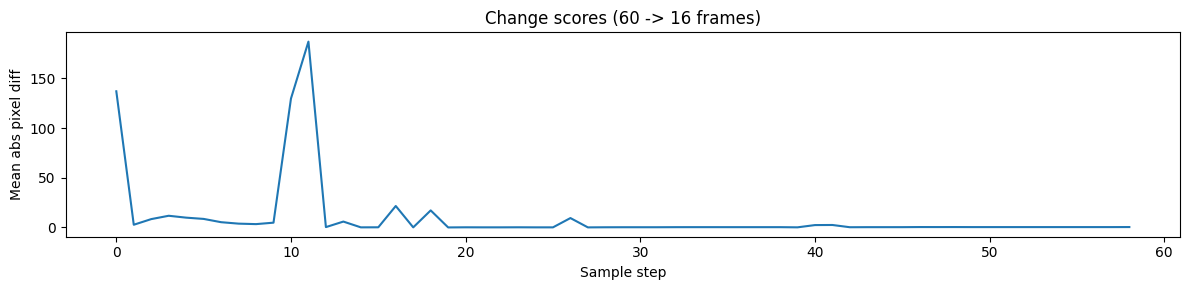

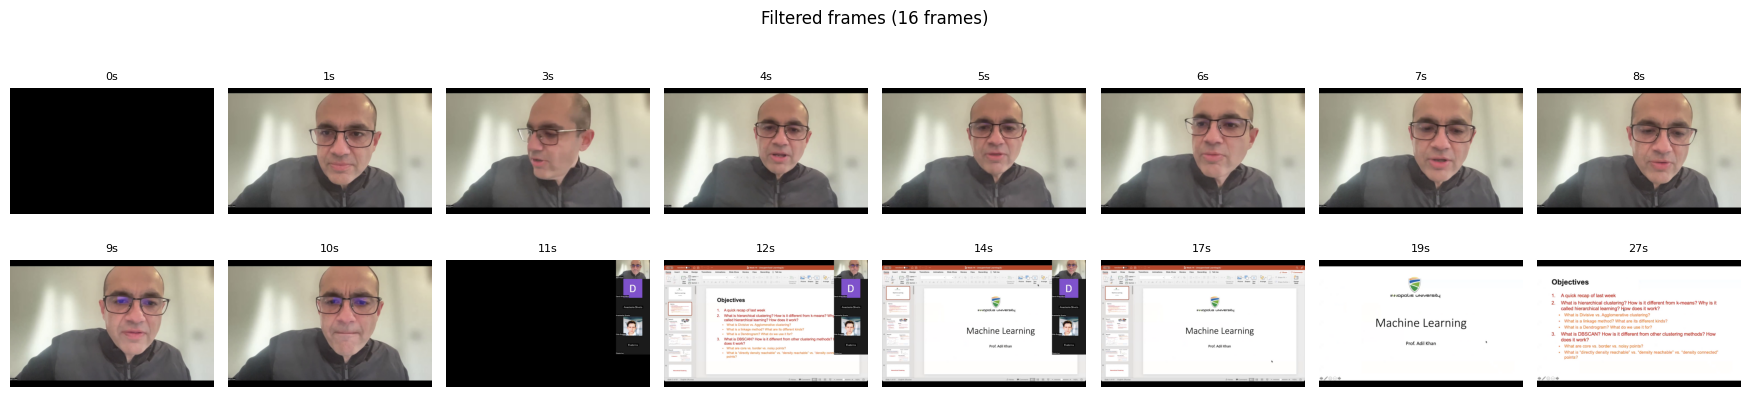

In [6]:
# Visualize results
show_filtering_comparison(
    result["original_frames"],
    result["filtered_frames"],
    result["original_timestamps"],
    result["filtered_timestamps"],
    result["keep_mask"],
    result["change_scores"],
    title="Pre-filtering results",
)

## Full Pipeline: Pre-filtering + MaxInfo Selection

This section demonstrates the complete pipeline:
1. Pre-filtering (change-based deduplication)
2. MaxInfo selection on filtered frames
3. Comparison with uniform baseline

In [7]:
def run_prefilter_maxinfo_pipeline(
    video_path: str,
    # Pre-filtering params
    prefilter_fps: float = 1.0,
    prefilter_max: int = 512,
    resize_hw=(32, 32),
    change_threshold: float = 6.0,
    # Selection params
    budget: int = 32,
    svd_rank: int = 8,
    tol: float = 0.3,
    batch_size: int = 16,
    # Video segment
    start_sec: float | None = None,
    end_sec: float | None = None,
    # Visualization
    show: bool = True,
    progress: bool = True,
):
    """
    Run complete pipeline: pre-filtering + MaxInfo selection.

    Returns dict with results from both stages.
    """
    if progress:
        print("=" * 60)
        print("Running Pre-filtering + MaxInfo Pipeline")
        print("=" * 60)

    # Stage 1: Pre-filtering
    prefilter_result = apply_prefilter(
        video_path=video_path,
        fps_sample=prefilter_fps,
        max_candidates=prefilter_max,
        start_sec=start_sec,
        end_sec=end_sec,
        resize_hw=resize_hw,
        change_threshold=change_threshold,
        keep_first=True,
        progress=progress,
    )

    filtered_frames = prefilter_result["filtered_frames"]
    filtered_timestamps = prefilter_result["filtered_timestamps"]
    filtered_orig_idx = prefilter_result["filtered_indices"]

    if len(filtered_frames) == 0:
        print("No frames after pre-filtering!")
        return None

    # Stage 2: Encode filtered frames for selection
    if progress:
        print(f"\nEncoding {len(filtered_frames)} filtered frames...")

    # Convert to PIL frames
    from PIL import Image
    filtered_pil = [Image.fromarray(f.astype("uint8")).convert("RGB") for f in filtered_frames]

    # Build temporal ids (simplified - one per frame)
    ts_group = [np.array([t], dtype=np.int32) for t in filtered_timestamps]

    # Stage 3: Load CLIP model
    CLIP_MODEL_NAME = "openai/clip-vit-large-patch14-336"
    if progress:
        print(f"Loading CLIP model: {CLIP_MODEL_NAME}")
    from maxinfo.clip import load_clip
    vision_model, vision_processor = load_clip(CLIP_MODEL_NAME, progress=progress)

    # Stage 4: Uniform selection (baseline on pre-filtered frames)
    if progress:
        print(f"\nRunning Uniform selection (budget={budget})...")
    uni_frames, uni_ts, uni_idx = uniform_select(filtered_pil, ts_group, budget=budget)

    if progress:
        print(f"Uniform selected {len(uni_idx)} frames")

    # Stage 5: MaxInfo selection
    if progress:
        print(f"\nRunning MaxInfo selection...")
    mi_frames, mi_ts, mi_idx = maxinfo_select_rect_maxvol(
        vision_model=vision_model,
        vision_processor=vision_processor,
        frames=filtered_pil,
        ts_group=ts_group,
        budget=budget,
        svd_rank=svd_rank,
        tol=tol,
        batch_size=batch_size,
        progress=progress,
    )

    if progress:
        print("=" * 60)
        print("Pipeline Complete!")
        print(f"   Pre-filtered: {len(filtered_frames)} frames")
        print(f"   Uniform: {len(uni_idx)} frames")
        print(f"   MaxInfo: {len(mi_idx)} frames")
        print("=" * 60)

    # Visualization
    if show:
        from maxinfo.viz import show_grid

        seg_label = f"[{start_sec}s-{end_sec}s]" if start_sec is not None else "[full]"

        show_grid(
            uni_frames,
            uni_idx,
            title=f"Uniform (budget={budget}) {seg_label}",
            cols=8,
        )
        show_grid(
            mi_frames,
            mi_idx,
            title=f"MaxInfo (budget={budget}) {seg_label}",
            cols=8,
        )

    return {
        "prefilter": prefilter_result,
        "uniform": {
            "frames": uni_frames,
            "indices": uni_idx,
            "timestamps": uni_ts,
        },
        "maxinfo": {
            "frames": mi_frames,
            "indices": mi_idx,
            "timestamps": mi_ts,
        },
    }


print("Pipeline function defined")

Pipeline function defined


Running Pre-filtering + MaxInfo Pipeline
Pre-filtering: ../data/lecture_14_ml.mp4
   Sample FPS: 0.2, Max candidates: 1024
   Change threshold: 3.0, Resize: (128, 128)
Loaded 600 frames from segment
Pre-filtering complete:
   Initial frames: 600
   After filtering: 48
   Reduction: 92.0%
   Kept frames: 48

Encoding 48 filtered frames...
Loading CLIP model: openai/clip-vit-large-patch14-336
📦 Loading CLIP model: openai/clip-vit-large-patch14-336...


Loading weights: 100%|██████████| 590/590 [00:00<00:00, 659.22it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded: openai/clip-vit-large-patch14-336
📦 Loading processor: openai/clip-vit-large-patch14-336...
✓ Processor loaded

Running Uniform selection (budget=32)...
Uniform selected 32 frames

Running MaxInfo selection...
🎯 MaxInfo selection: 48 frames → budget=32, rank=6, tol=0.3


🔍 Extracting CLIP features: 100%|██████████| 3/3 [01:07<00:00, 22.38s/it]


📐 Running SVD (rank=6)...
✓ SVD complete: Qs shape = (48, 6)
📊 Running MaxVol greedy selection (tol=0.3, n=48, r=6)...
✓ Selected 38 pivots from 48 candidates
📉 Subsampling from 38 to 32 pivots...
✓ MaxInfo selection complete: 32 frames selected
Pipeline Complete!
   Pre-filtered: 48 frames
   Uniform: 32 frames
   MaxInfo: 32 frames


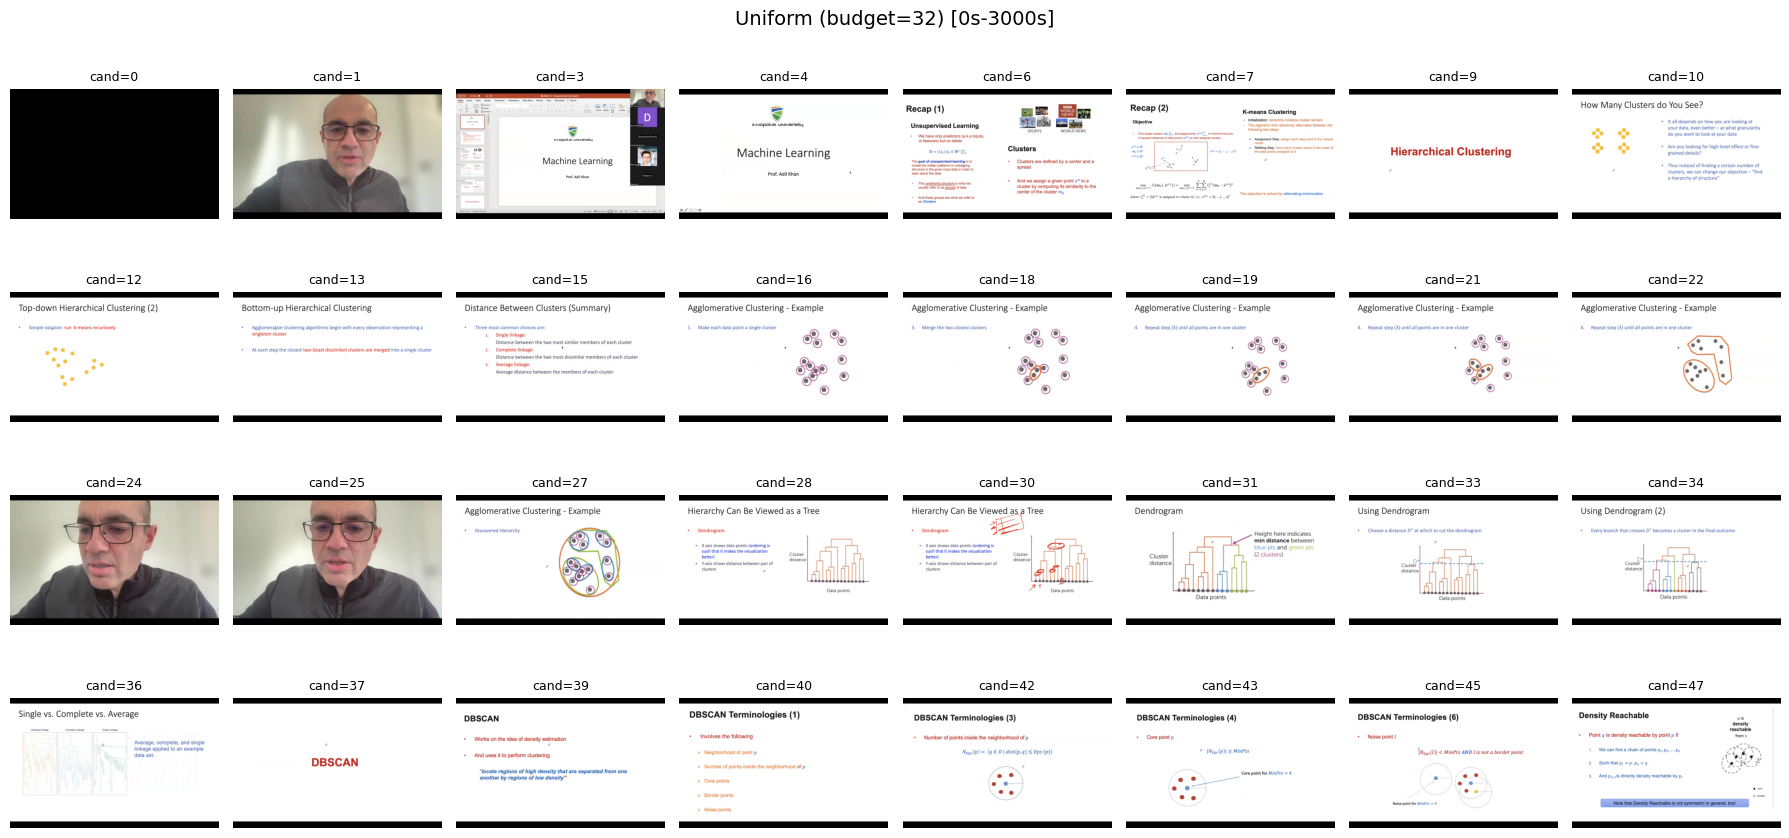

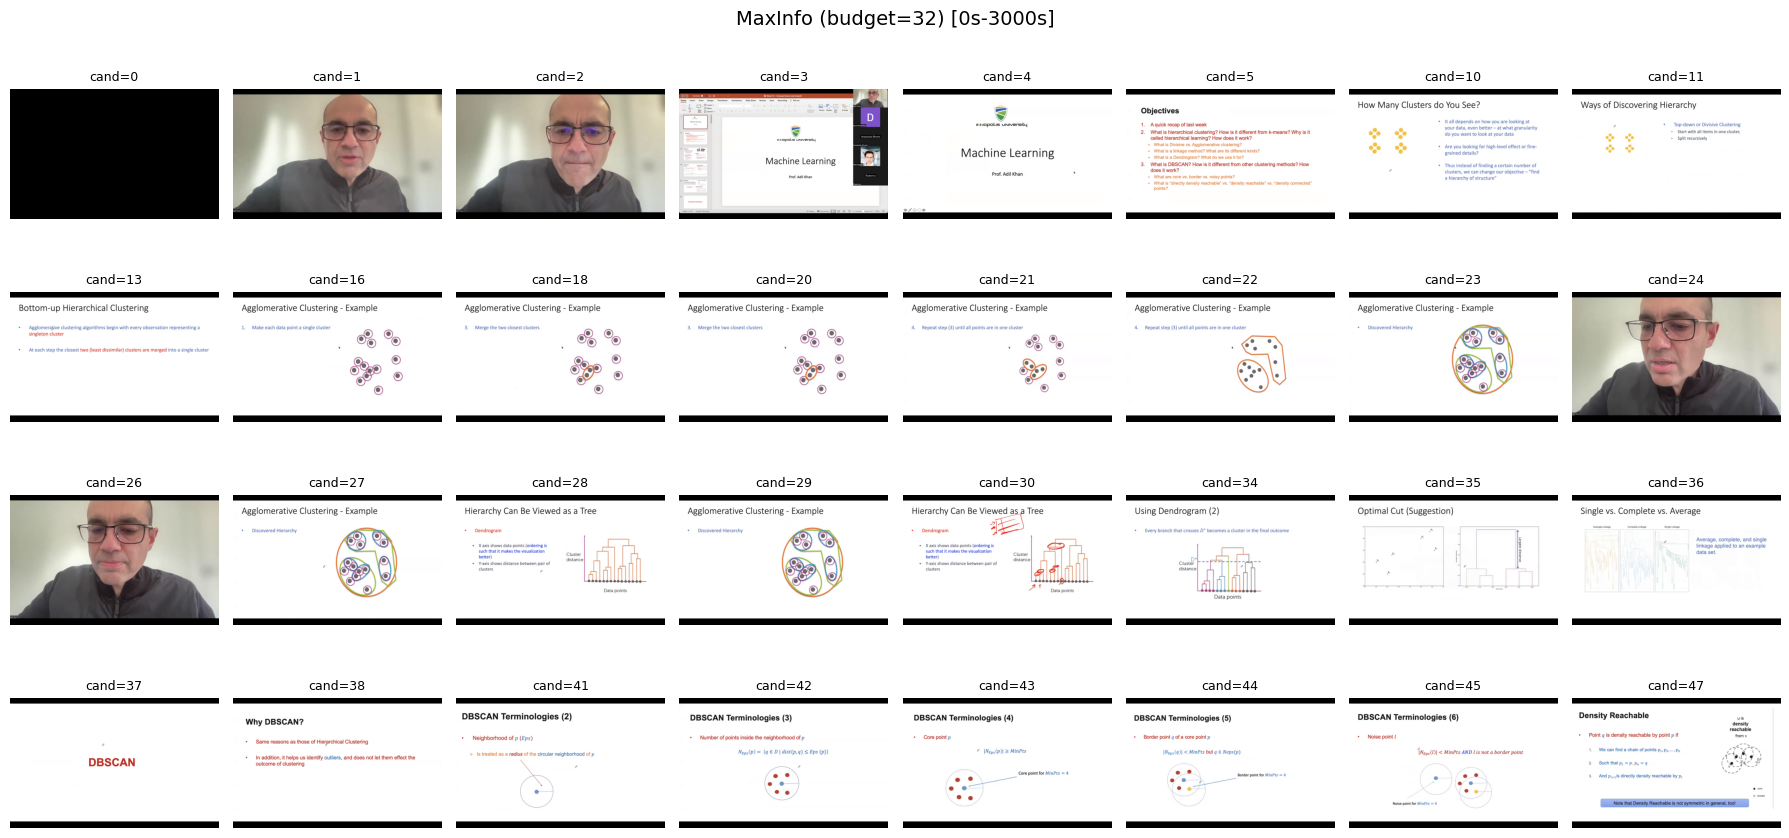

In [14]:
# Run the complete pipeline
result = run_prefilter_maxinfo_pipeline(
    video_path="../data/lecture_14_ml.mp4",
    # Pre-filtering
    prefilter_fps=0.2,
    prefilter_max=1024,
    resize_hw=(128, 128),
    change_threshold=3.0,
    # Selection
    budget=32,
    svd_rank=6,
    tol=0.3,
    batch_size=16,
    # Segment (optional)
    start_sec=0,
    end_sec=3000,  # First 2 minutes
    show=True,
    progress=True,
)

In [15]:
import maxinfo

print('maxinfo imported:', maxinfo.__name__)
# Edit this path to point to your video
video_path = r"../data/lecture_14_ml.mp4"

# Optional: restrict to a segment
start_sec = 0  # e.g. 10*60
end_sec = 3000    # e.g. 20*60

out = maxinfo.compare_sampling_on_video(
    video_path=video_path,
    choose_fps=0.2,
    max_candidates=1024,
    budget=32,
    svd_rank=6,
    tol=0.3,
    batch_size=16,
    start_sec=start_sec,
    end_sec=end_sec,
    show=True,
)

print('Uniform indices:', out['uniform']['indices'])
print('MaxInfo indices:', out['maxinfo']['indices'])

maxinfo imported: maxinfo
🚀 Starting MaxInfo pipeline
   Video: ../data/lecture_14_ml.mp4
   FPS sample: 0.2, Max candidates: 1024
   Segment: 0s - 3000s
📦 Loading CLIP model: openai/clip-vit-large-patch14-336...


Loading weights: 100%|██████████| 590/590 [00:00<00:00, 979.93it/s, Materializing param=visual_projection.weight]                                 
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded: openai/clip-vit-large-patch14-336
📦 Loading processor: openai/clip-vit-large-patch14-336...
✓ Processor loaded
📹 Loading video candidates (fps=0.2, max=1024)...
✓ Loaded 600 frames from video
📊 Running uniform selection (budget=32)...
✓ Uniform selected 32 frames
🎯 Running MaxInfo selection...
🎯 MaxInfo selection: 600 frames → budget=32, rank=6, tol=0.3


🔍 Extracting CLIP features:   8%|▊         | 3/38 [01:15<14:43, 25.24s/it]


KeyboardInterrupt: 

In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from maxinfo import load_video_segment, maxinfo_select_rect_maxvol
from maxinfo.clip import load_clip

def _to_pil(frames_np):
    return [Image.fromarray(f.astype("uint8")).convert("RGB") for f in frames_np]

def time_maxinfo_run(
    video_path: str,
    *,
    fps_sample: float,
    max_candidates: int,
    start_sec: float | None,
    end_sec: float | None,
    # prefilter
    use_prefilter: bool,
    resize_hw=(64, 64),
    change_threshold: float = 3.0,
    keep_first: bool = True,
    # maxinfo
    budget: int = 32,
    svd_rank: int = 6,
    tol: float = 0.3,
    batch_size: int = 16,
    # clip
    clip_model_name: str = "openai/clip-vit-large-patch14-336",
    vision_model=None,
    vision_processor=None,
    progress: bool = False,
):
    timings = {}

    # 0) Load video segment
    t0 = time.perf_counter()
    frames_np, timestamps, orig_frame_idx, segment, duration, native_fps = load_video_segment(
        video_path=video_path,
        fps_sample=fps_sample,
        max_candidates=max_candidates,
        start_sec=start_sec,
        end_sec=end_sec,
        force_sample=True,
    )
    timings["load_video"] = time.perf_counter() - t0

    # 1) Optional prefilter
    if use_prefilter and len(frames_np) > 1:
        t0 = time.perf_counter()
        keep_mask, change_scores = change_dedup_indices(
            frames_np,
            resize_hw=resize_hw,
            change_threshold=change_threshold,
            keep_first=keep_first,
        )
        frames_np = frames_np[keep_mask]
        timestamps = [t for t, k in zip(timestamps, keep_mask) if k]
        orig_frame_idx = [fi for fi, k in zip(orig_frame_idx, keep_mask) if k]
        timings["prefilter"] = time.perf_counter() - t0
    else:
        timings["prefilter"] = 0.0

    # 2) Prepare frames + ts_group
    t0 = time.perf_counter()
    frames_pil = _to_pil(frames_np)
    ts_group = [np.array([t], dtype=np.int32) for t in timestamps]
    timings["prep_frames"] = time.perf_counter() - t0

    # 3) Load CLIP once (pass in from outside when benchmarking repeated runs)
    if vision_model is None or vision_processor is None:
        t0 = time.perf_counter()
        vision_model, vision_processor = load_clip(clip_model_name, progress=progress)
        timings["load_clip"] = time.perf_counter() - t0
    else:
        timings["load_clip"] = 0.0

    # 4) MaxInfo selection (includes embedding extraction inside maxinfo_select_rect_maxvol)
    t0 = time.perf_counter()
    mi_frames, mi_ts, mi_idx = maxinfo_select_rect_maxvol(
        vision_model=vision_model,
        vision_processor=vision_processor,
        frames=frames_pil,
        ts_group=ts_group,
        budget=budget,
        svd_rank=svd_rank,
        tol=tol,
        batch_size=batch_size,
        progress=progress,
    )
    timings["maxinfo_select"] = time.perf_counter() - t0

    timings["total"] = sum(timings.values())

    meta = {
        "n_frames_in": len(frames_np),
        "n_selected": len(mi_idx),
    }
    return timings, meta, (vision_model, vision_processor)

def benchmark_and_plot(
    video_path: str,
    *,
    fps_sample=0.2,
    max_candidates=1024,
    start_sec=0,
    end_sec=3000,
    resize_hw=(128, 128),
    change_threshold=3.0,
    budget=32,
    svd_rank=6,
    tol=0.3,
    batch_size=16,
    runs=3,
):
    # Load CLIP once to avoid counting model load in the comparison
    vm, vp = load_clip("openai/clip-vit-large-patch14-336", progress=False)

    stages = ["load_video", "prefilter", "prep_frames", "maxinfo_select"]
    records = {"no_prefilter": {s: [] for s in stages+["total"]},
               "prefilter":    {s: [] for s in stages+["total"]}}

    for _ in range(runs):
        t_np, meta_np, _ = time_maxinfo_run(
            video_path,
            fps_sample=fps_sample, max_candidates=max_candidates,
            start_sec=start_sec, end_sec=end_sec,
            use_prefilter=False,
            resize_hw=resize_hw, change_threshold=change_threshold,
            budget=budget, svd_rank=svd_rank, tol=tol, batch_size=batch_size,
            vision_model=vm, vision_processor=vp,
            progress=False,
        )
        t_pf, meta_pf, _ = time_maxinfo_run(
            video_path,
            fps_sample=fps_sample, max_candidates=max_candidates,
            start_sec=start_sec, end_sec=end_sec,
            use_prefilter=True,
            resize_hw=resize_hw, change_threshold=change_threshold,
            budget=budget, svd_rank=svd_rank, tol=tol, batch_size=batch_size,
            vision_model=vm, vision_processor=vp,
            progress=False,
        )

        for s in stages + ["total"]:
            records["no_prefilter"][s].append(t_np[s])
            records["prefilter"][s].append(t_pf[s])

    # Mean times
    mean_np = {k: float(np.mean(v)) for k, v in records["no_prefilter"].items()}
    mean_pf = {k: float(np.mean(v)) for k, v in records["prefilter"].items()}

    # Plot: total time + delta
    labels = ["No prefilter", "Prefilter"]
    totals = [mean_np["total"], mean_pf["total"]]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, totals)
    plt.ylabel("Seconds (mean)")
    plt.title(f"MaxInfo runtime (mean over {runs} runs)\nΔ = {totals[0]-totals[1]:.2f}s (positive means prefilter faster)")
    plt.tight_layout()
    plt.show()

    # Plot: per-stage stacked bars (helps you see where time moved)
    plt.figure(figsize=(9, 4))
    bottoms = np.zeros(2)
    for s in stages:
        vals = [mean_np[s], mean_pf[s]]
        plt.bar(labels, vals, bottom=bottoms, label=s)
        bottoms += np.array(vals)
    plt.ylabel("Seconds (mean)")
    plt.title("Runtime breakdown by stage")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"mean_no_prefilter": mean_np, "mean_prefilter": mean_pf}


import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from maxinfo import (
    load_video_segment,
    uniform_select,
    maxinfo_select_rect_maxvol,
)
from maxinfo.clip import load_clip
from maxinfo.viz import show_grid


def run_sampler(
    *,
    video_path,
    fps_sample,
    max_candidates,
    start_sec,
    end_sec,
    use_prefilter,
    resize_hw,
    change_threshold,
    sampler,              # "uniform" | "maxinfo"
    budget,
    svd_rank,
    tol,
    batch_size,
    vision_model,
    vision_processor,
    progress=False,
):
    timings = {}

    # ---------------- Load video ----------------
    t0 = time.perf_counter()
    frames_np, timestamps, orig_idx, *_ = load_video_segment(
        video_path,
        fps_sample=fps_sample,
        max_candidates=max_candidates,
        start_sec=start_sec,
        end_sec=end_sec,
        force_sample=True,
    )
    timings["load"] = time.perf_counter() - t0

    # ---------------- Prefilter ----------------
    if use_prefilter and len(frames_np) > 1:
        t0 = time.perf_counter()
        keep_mask, _ = change_dedup_indices(
            frames_np,
            resize_hw=resize_hw,
            change_threshold=change_threshold,
            keep_first=True,
        )
        frames_np = frames_np[keep_mask]
        timestamps = [t for t, k in zip(timestamps, keep_mask) if k]
        orig_idx = [i for i, k in zip(orig_idx, keep_mask) if k]
        timings["prefilter"] = time.perf_counter() - t0
    else:
        timings["prefilter"] = 0.0

    # ---------------- Prepare ----------------
    frames_pil = [Image.fromarray(f).convert("RGB") for f in frames_np]
    ts_group = [np.array([t], dtype=np.int32) for t in timestamps]

    # ---------------- Sample ----------------
    t0 = time.perf_counter()
    if sampler == "uniform":
        frames_out, ts_out, idx_out = uniform_select(
            frames_pil, ts_group, budget=budget
        )
    else:
        frames_out, ts_out, idx_out = maxinfo_select_rect_maxvol(
            vision_model=vision_model,
            vision_processor=vision_processor,
            frames=frames_pil,
            ts_group=ts_group,
            budget=budget,
            svd_rank=svd_rank,
            tol=tol,
            batch_size=batch_size,
            progress=progress,
        )
    timings["select"] = time.perf_counter() - t0

    timings["total"] = sum(timings.values())

    return {
        "frames": frames_out,
        "indices": idx_out,
        "timestamps": ts_out,
        "timings": timings,
        "n_candidates": len(frames_np),
    }

video_path = "../data/lecture_14_ml.mp4"

fps_sample = 0.2
max_candidates = 1024
start_sec = 0
end_sec = 3000

budget = 32
svd_rank = 6
tol = 0.3
batch_size = 16

resize_hw = (128, 128)
change_threshold = 3.0

vision_model, vision_processor = load_clip(
    "openai/clip-vit-large-patch14-336",
    progress=True,
)

configs = [
    ("Uniform",  False, "uniform"),
    ("MaxInfo",  False, "maxinfo"),
    ("Uniform+PF", True, "uniform"),
    ("MaxInfo+PF", True, "maxinfo"),
]

results = {}

for name, use_pf, sampler in configs:
    print(f"\nRunning {name}")
    results[name] = run_sampler(
        video_path=video_path,
        fps_sample=fps_sample,
        max_candidates=max_candidates,
        start_sec=start_sec,
        end_sec=end_sec,
        use_prefilter=use_pf,
        resize_hw=resize_hw,
        change_threshold=change_threshold,
        sampler=sampler,
        budget=budget,
        svd_rank=svd_rank,
        tol=tol,
        batch_size=batch_size,
        vision_model=vision_model,
        vision_processor=vision_processor,
        progress=True,
    )


📦 Loading CLIP model: openai/clip-vit-large-patch14-336...


Loading weights: 100%|██████████| 590/590 [00:00<00:00, 862.99it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded: openai/clip-vit-large-patch14-336
📦 Loading processor: openai/clip-vit-large-patch14-336...
✓ Processor loaded

Running Uniform

Running MaxInfo
🎯 MaxInfo selection: 600 frames → budget=32, rank=6, tol=0.3


🔍 Extracting CLIP features: 100%|██████████| 38/38 [13:04<00:00, 20.65s/it]


📐 Running SVD (rank=6)...
✓ SVD complete: Qs shape = (600, 6)
📊 Running MaxVol greedy selection (tol=0.3, n=600, r=6)...
✓ Selected 69 pivots from 600 candidates
📉 Subsampling from 69 to 32 pivots...
✓ MaxInfo selection complete: 32 frames selected

Running Uniform+PF

Running MaxInfo+PF
🎯 MaxInfo selection: 48 frames → budget=32, rank=6, tol=0.3


🔍 Extracting CLIP features: 100%|██████████| 3/3 [01:08<00:00, 22.82s/it]

📐 Running SVD (rank=6)...
✓ SVD complete: Qs shape = (48, 6)
📊 Running MaxVol greedy selection (tol=0.3, n=48, r=6)...
✓ Selected 38 pivots from 48 candidates
📉 Subsampling from 38 to 32 pivots...
✓ MaxInfo selection complete: 32 frames selected


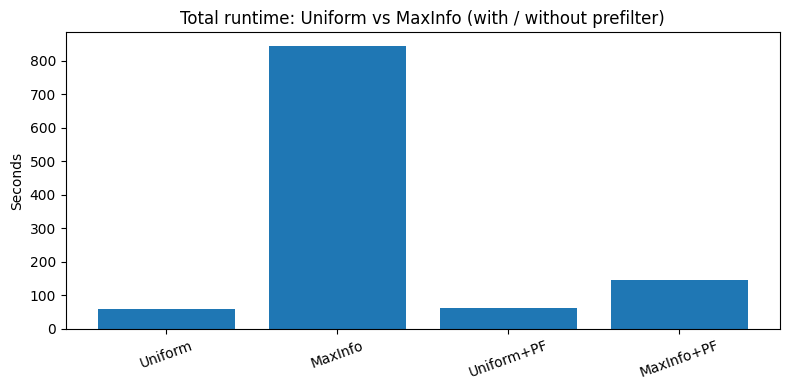

In [18]:
labels = list(results.keys())
times = [results[k]["timings"]["total"] for k in labels]

plt.figure(figsize=(8, 4))
plt.bar(labels, times)
plt.ylabel("Seconds")
plt.title("Total runtime: Uniform vs MaxInfo (with / without prefilter)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



Uniform:
Selected indices: [0, 19, 38, 57, 77, 96, 115, 135, 154, 173, 193, 212, 231, 251, 270, 289, 309, 328, 347, 367, 386, 405, 425, 444, 463, 483, 502, 521, 541, 560, 579, 599]


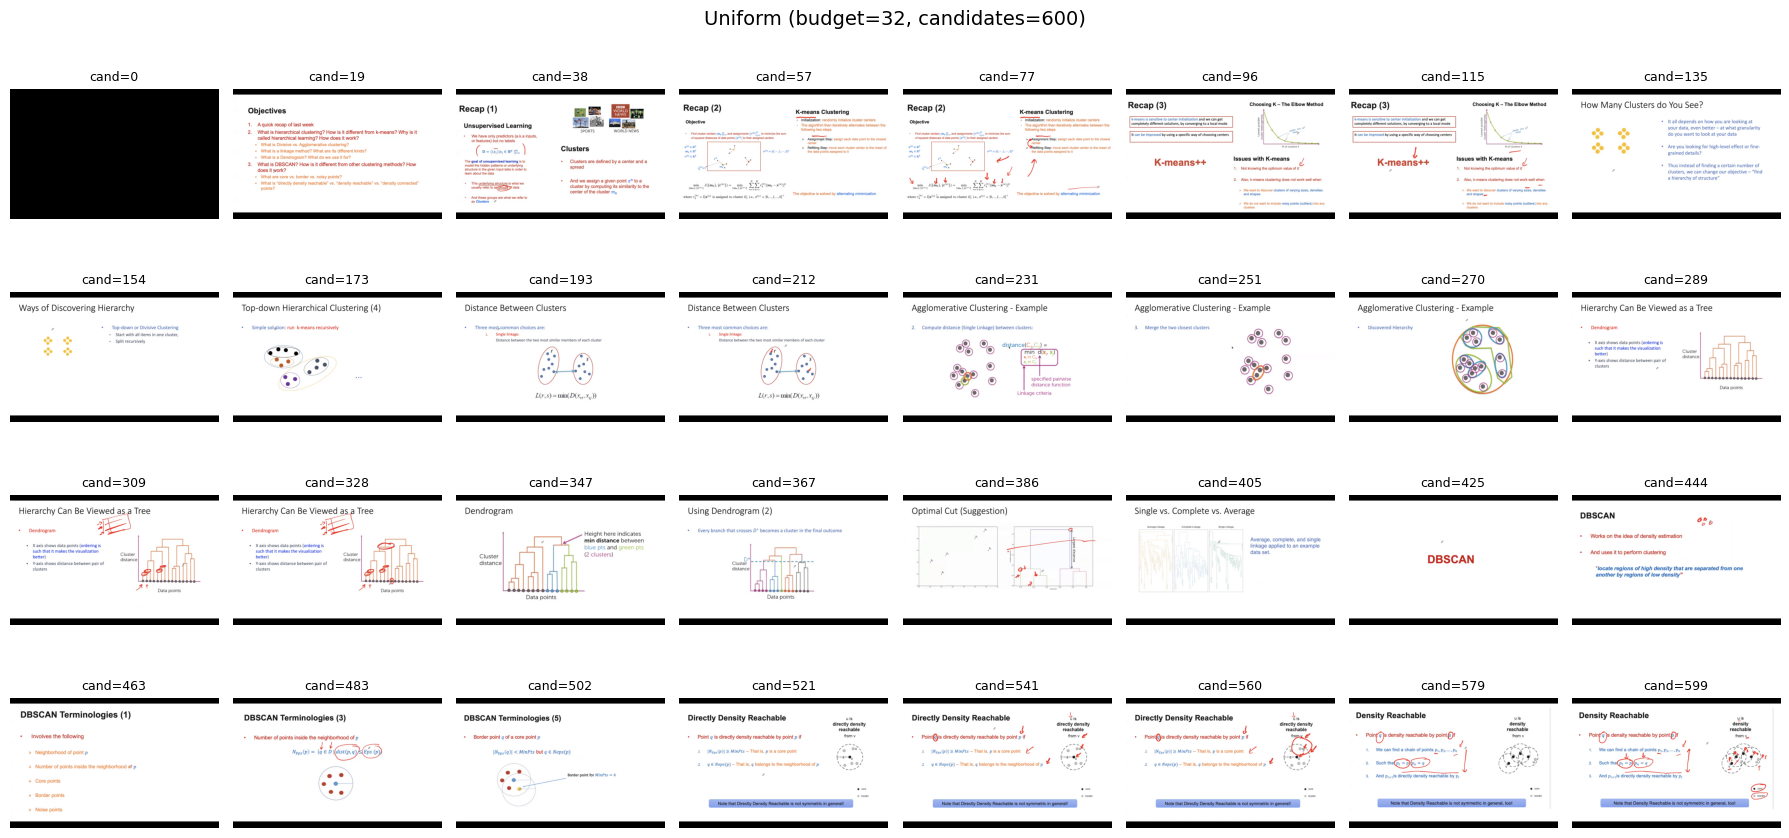


MaxInfo:
Selected indices: [0, 11, 14, 16, 54, 57, 233, 235, 256, 269, 276, 297, 299, 301, 303, 311, 403, 420, 423, 432, 434, 437, 452, 506, 512, 514, 518, 536, 539, 542, 544, 547]


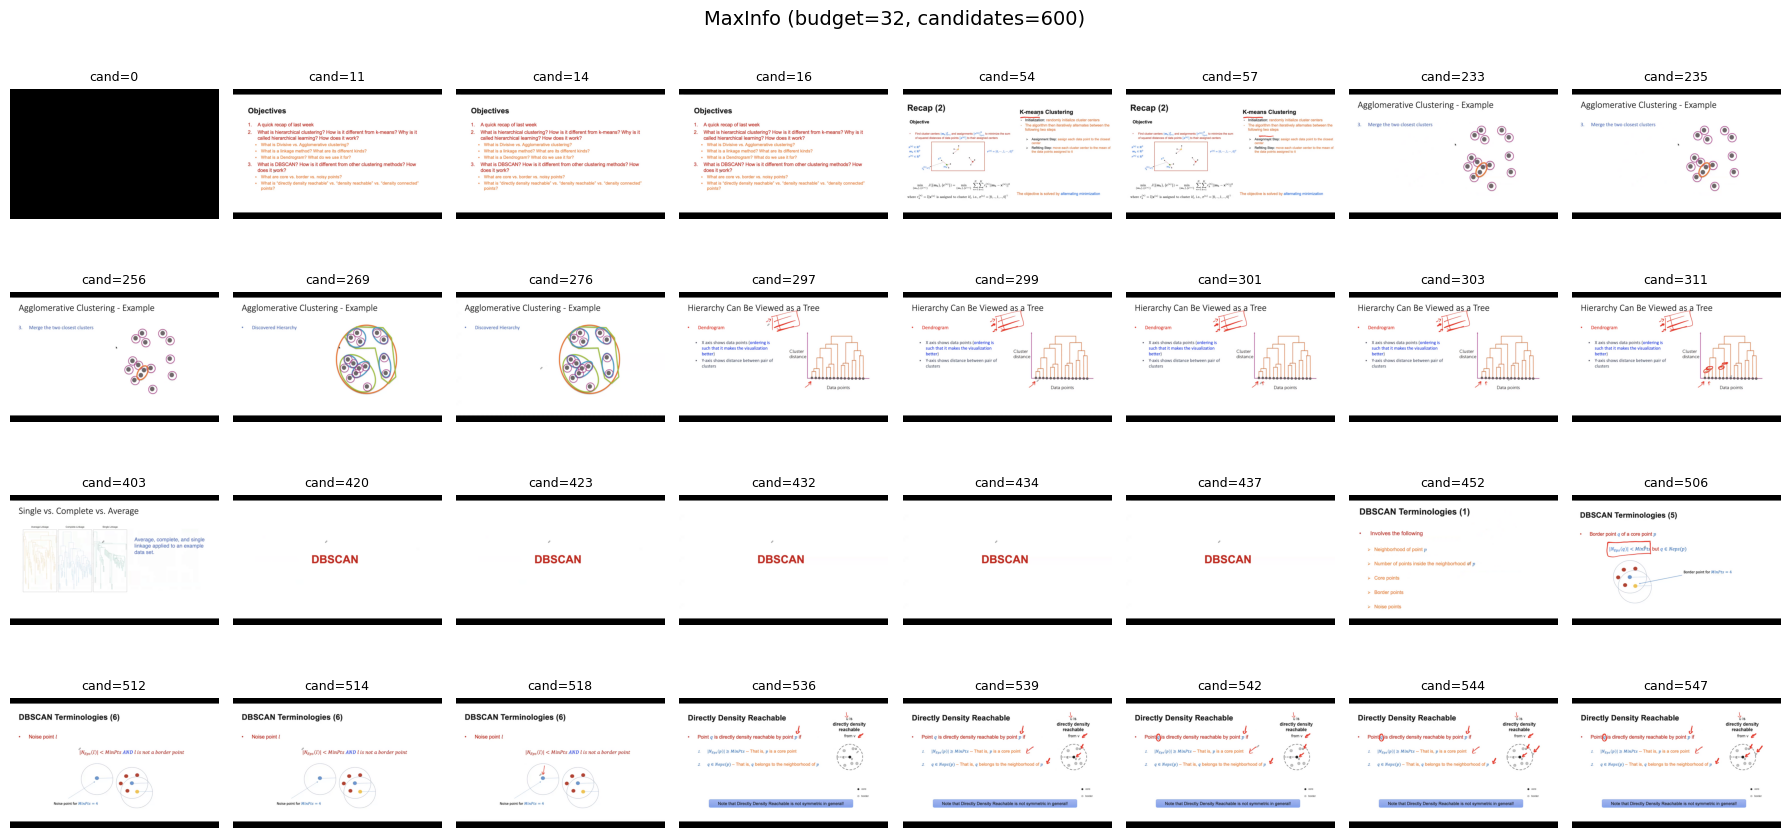


Uniform+PF:
Selected indices: [0, 1, 3, 4, 6, 7, 9, 10, 12, 13, 15, 16, 18, 19, 21, 22, 24, 25, 27, 28, 30, 31, 33, 34, 36, 37, 39, 40, 42, 43, 45, 47]


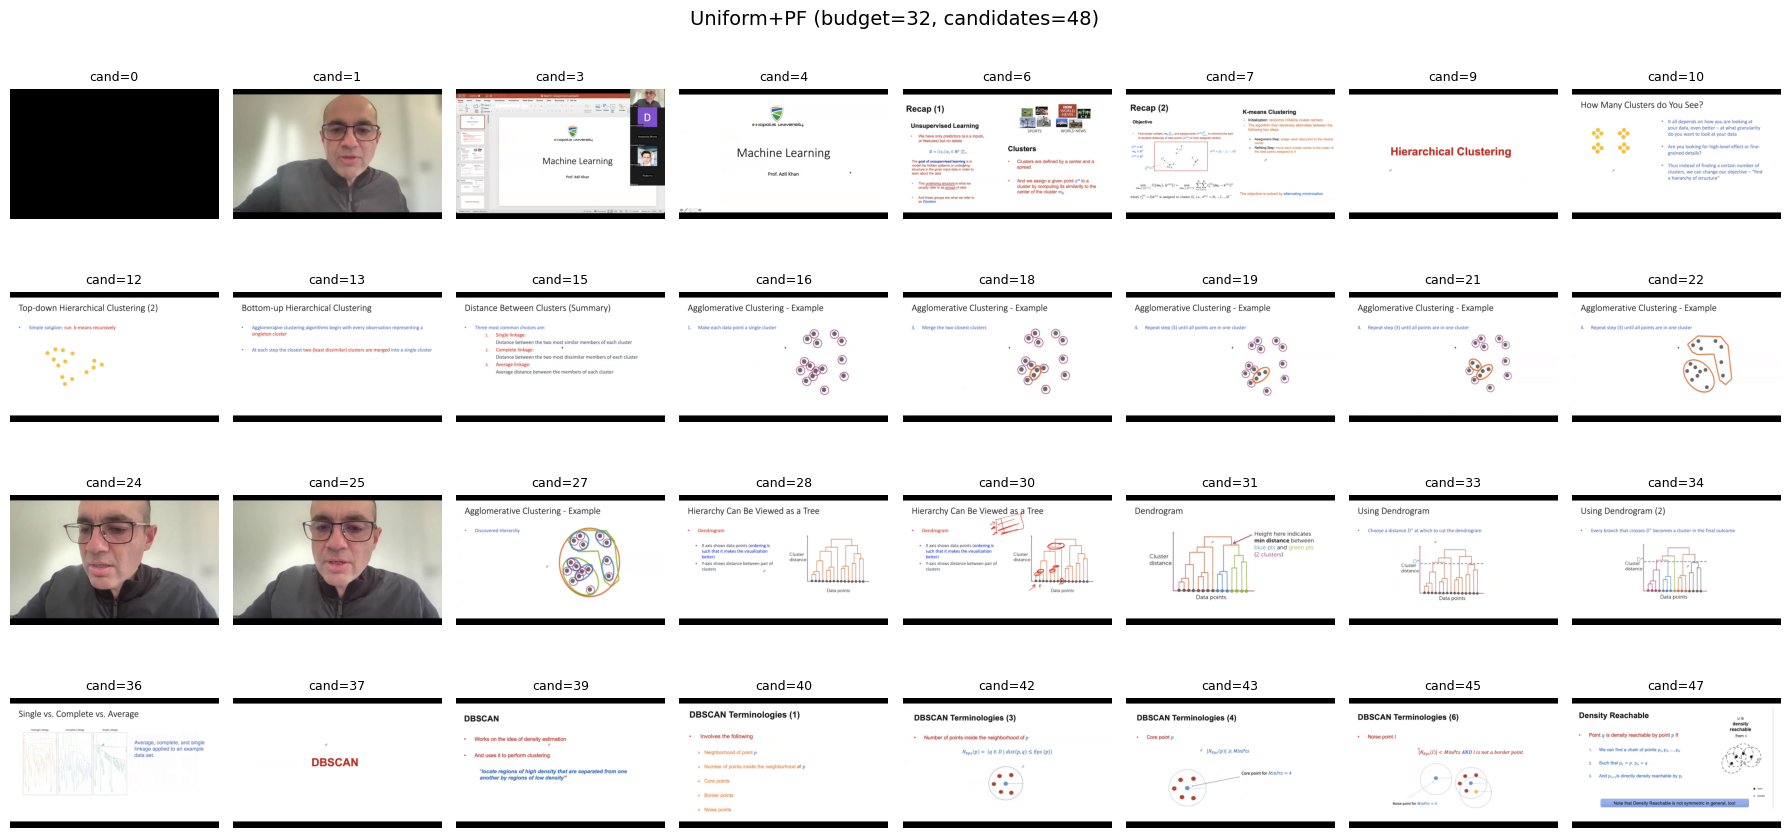


MaxInfo+PF:
Selected indices: [0, 1, 2, 3, 4, 5, 10, 11, 13, 16, 18, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 33, 34, 36, 37, 38, 41, 42, 43, 44, 45, 47]


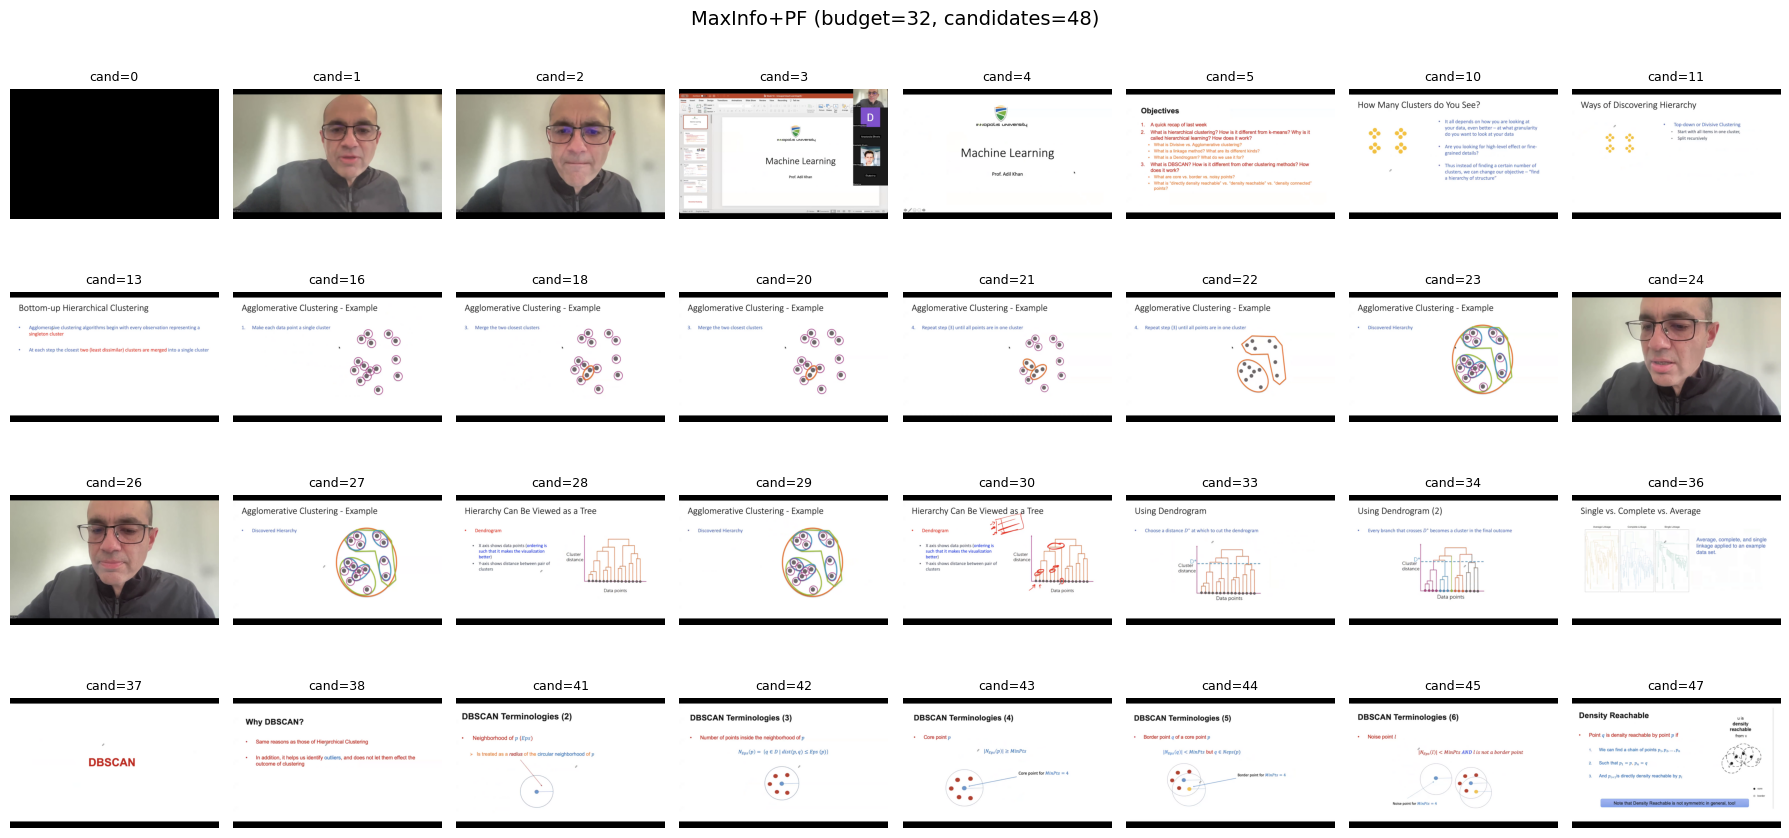

In [19]:
for name, res in results.items():
    print(f"\n{name}:")
    print("Selected indices:", res["indices"])

    show_grid(
        res["frames"],
        res["indices"],
        cols=8,
        title=f"{name} (budget={budget}, candidates={res['n_candidates']})",
    )


## Summary

This notebook demonstrates:

1. **Pre-filtering**: Using pixel-based change detection to reduce redundant frames before expensive CLIP embedding extraction

2. **MaxInfo Module**: Using the module's functions:
   - `load_video_segment` for video decoding
   - `uniform_select` for baseline comparison
   - `maxinfo_select_rect_maxvol` for keyframe selection
   - `load_clip` for CLIP model loading

3. **Benefits of Pre-filtering**:
   - Reduces number of frames passed to CLIP
   - Preserves temporal coverage while removing duplicates
   - Can be tuned via `change_threshold` and `resize_hw` parameters